# BBO Capstone — Round 13 (Final): Strategy Refinement & Submission

**Author:** Gian Franco Cattaneo  
**Programme:** Executive Master in Machine Learning & AI — Imperial Business School  
**Component:** 24.1 — Refining strategies for the black-box optimisation challenge  
**Objective:** Maximisation across 8 black-box functions (dimensions d = 2–8).

This notebook ingests the complete 12-round dataset and produces the **final** round of queries.
It runs the established **GP–EI** surrogate pipeline as a *cross-check*, then applies the
**override doctrine**: where a clean empirical signal — ridge geometry, monotone gradient,
hard anchor coordinate, or parabolic vertex — is more reliable than a data-starved GP
extrapolation, the empirical signal governs. On a terminal round the policy is **pure
exploitation** (ε → 0): the trust region collapses and EI's exploration bonus is suppressed.

Reinforcement-learning framing of the project arc:
- **Early rounds** — MAB-style exploration to locate each function's mass.
- **Round 4→5** — reward-signal correction (minimisation negated into a consistent maximisation EI).
- **Middle rounds** — feedback-driven local ascent (Q-learning-like value refinement).
- **Round 13 (here)** — terminal exploitation of the learned policy.

## 1. Environment

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from numpy import array, float64  # used by the embedded-data parser

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

np.random.seed(7)
LB, UB = 0.0, 0.999999   # portal box; upper bound clipped at 0.999999
F = 8
NAMES = ["f1(2D)", "f2(2D)", "f3(3D)", "f4(4D)", "f5(4D)", "f6(5D)", "f7(6D)", "f8(8D)"]

## 2. Data (embedded — 12 rounds)

The full query history and realised outputs are embedded so the notebook is fully
reproducible inside the repo with no external file dependency. Multi-line wrapped
arrays (the 8-D function) are re-joined before parsing.

In [2]:
INPUTS_RAW = r"""[array([0.034388, 0.909319]), array([0.695196, 0.39597 ]), array([0.548145, 0.174647, 0.303245]), array([0.440429, 0.425456, 0.378357, 0.397088]), array([0.      , 0.675974, 0.999999, 0.999999]), array([0.464677, 0.24211 , 0.574863, 0.999999, 0.      ]), array([0.      , 0.241713, 0.327655, 0.218095, 0.375335, 0.747501]), array([0.064016, 0.008062, 0.123268, 0.      , 0.999999, 0.381742,
       0.031402, 0.80601 ])]
[array([0.999999, 0.999999]), array([0.698486, 0.      ]), array([0.850892, 0.035316, 0.936193]), array([0.999999, 0.      , 0.      , 0.365908]), array([0.      , 0.      , 0.999999, 0.999999]), array([0.142733, 0.321812, 0.416485, 0.999999, 0.304415]), array([0.      , 0.302741, 0.      , 0.187177, 0.      , 0.167182]), array([0.096074, 0.      , 0.581701, 0.      , 0.999999, 0.38389 ,
       0.202189, 0.999999])]
[array([0.25, 0.25]), array([0.695, 0.396]), array([0.3, 0.5, 0.7]), array([0.44 , 0.425, 0.378, 0.397]), array([0.      , 0.85    , 0.999999, 0.999999]), array([0.5, 0.5, 0.5, 0.5, 0.5]), array([0.   , 0.242, 0.328, 0.218, 0.375, 0.748]), array([0.064   , 0.008   , 0.12    , 0.      , 0.999999, 0.382   ,
       0.031   , 0.806   ])]
[array([0.5, 0.5]), array([0.7, 0.2]), array([0.95, 0.01, 0.99]), array([0.999999, 0.      , 0.      , 0.7     ]), array([0. , 0. , 0.5, 0.5]), array([0.3, 0.4, 0.6, 0.2, 0.6]), array([0.  , 0.15, 0.  , 0.1 , 0.  , 0.1 ]), array([0.1     , 0.      , 0.8     , 0.      , 0.999999, 0.38    ,
       0.35    , 0.999999])]
[array([0.472781, 0.505546]), array([0.695211, 0.39597 ]), array([0.511275, 0.215264, 0.371049]), array([0.455, 0.415, 0.385, 0.395]), array([0.      , 0.999999, 0.999999, 0.999999]), array([0.758817, 0.272673, 0.522143, 0.999999, 0.      ]), array([0.   , 0.26 , 0.34 , 0.232, 0.395, 0.752]), array([0.04    , 0.      , 0.09    , 0.005   , 0.999999, 0.367013,
       0.02    , 0.78    ])]
[array([0.445562, 0.511092]), array([0.693, 0.397]), array([0.49 , 0.23 , 0.395]), array([0.43 , 0.43 , 0.375, 0.4  ]), array([0.005   , 0.999999, 0.999999, 0.999999]), array([0.45    , 0.24    , 0.58    , 0.999999, 0.      ]), array([0.   , 0.238, 0.325, 0.215, 0.37 , 0.743]), array([0.063   , 0.008   , 0.123   , 0.      , 0.999999, 0.382   ,
       0.031   , 0.807   ])]
[array([0.475, 0.503]), array([0.697, 0.393]), array([0.478, 0.223, 0.408]), array([0.42 , 0.44 , 0.373, 0.403]), array([0.      , 0.999999, 0.999999, 0.999999]), array([0.468   , 0.241   , 0.572   , 0.999999, 0.      ]), array([0.   , 0.235, 0.322, 0.212, 0.367, 0.74 ]), array([0.064016, 0.008062, 0.124   , 0.      , 0.999999, 0.381742,
       0.031402, 0.80601 ])]
[array([0.477, 0.501]), array([0.695, 0.394]), array([0.465, 0.222, 0.421]), array([0.428, 0.432, 0.374, 0.401]), array([0.      , 0.999999, 0.999999, 0.999999]), array([0.46    , 0.242   , 0.575   , 0.999999, 0.      ]), array([0.   , 0.232, 0.319, 0.209, 0.364, 0.737]), array([0.064016, 0.008062, 0.126   , 0.      , 0.999999, 0.381742,
       0.031402, 0.80601 ])]
[array([0.479, 0.499]), array([0.6952, 0.3965]), array([0.48 , 0.221, 0.406]), array([0.426, 0.434, 0.373, 0.402]), array([0.      , 0.999999, 0.999999, 0.999999]), array([0.465   , 0.241   , 0.576   , 0.999999, 0.      ]), array([0.   , 0.229, 0.316, 0.206, 0.361, 0.734]), array([0.064016, 0.008062, 0.128   , 0.      , 0.999999, 0.381742,
       0.031402, 0.80601 ])]
[array([0.481, 0.497]), array([0.696 , 0.3955]), array([0.476, 0.225, 0.41 ]), array([0.43 , 0.43 , 0.376, 0.399]), array([0.003   , 0.999999, 0.999999, 0.999999]), array([0.466   , 0.242   , 0.575   , 0.999999, 0.      ]), array([0.   , 0.226, 0.31 , 0.2  , 0.355, 0.73 ]), array([0.064016, 0.008062, 0.13    , 0.      , 0.999999, 0.381742,
       0.031402, 0.80601 ])]
[array([0.483, 0.495]), array([0.6954, 0.3956]), array([0.4775, 0.2235, 0.4085]), array([0.4285, 0.4315, 0.3745, 0.4005]), array([0.01    , 0.999999, 0.999999, 0.999999]), array([0.465   , 0.2421  , 0.5749  , 0.999999, 0.      ]), array([0.   , 0.223, 0.307, 0.197, 0.352, 0.727]), array([0.064016, 0.008062, 0.133   , 0.      , 0.999999, 0.381742,
       0.031402, 0.80601 ])]
[array([0.485, 0.493]), array([0.695196, 0.39597 ]), array([0.477, 0.224, 0.409]), array([0.429299, 0.427594, 0.37051 , 0.404482]), array([0.02    , 0.999999, 0.999999, 0.999999]), array([0.462525, 0.245506, 0.578888, 0.999999, 0.      ]), array([0.   , 0.22 , 0.304, 0.194, 0.349, 0.724]), array([0.064016, 0.008062, 0.131   , 0.      , 0.999999, 0.381742,
       0.031402, 0.80601 ])]
"""

OUTPUTS_RAW = r"""[np.float64(-2.4674747069022486e-270), np.float64(0.7237404632835625), np.float64(-0.08911956876452833), np.float64(0.25957575200735095), np.float64(2105.928152398213), np.float64(-0.5507747202906804), np.float64(2.207308607344047), np.float64(9.8595486103895)]
[np.float64(1.517648729565899e-192), np.float64(0.5297658866453171), np.float64(-0.23982430098711077), np.float64(-27.859767965401783), np.float64(1616.625747348229), np.float64(-1.0045153236844038), np.float64(0.050978228653516464), np.float64(9.2933769573024)]
[np.float64(9.797748409814019e-42), np.float64(0.5263661301012157), np.float64(-0.1139602029925284), np.float64(0.2748080020297299), np.float64(2932.694991178572), np.float64(-1.0159268487405835), np.float64(2.2071746109147172), np.float64(9.8591545999995)]
[np.float64(2.6752879910742468e-09), np.float64(0.5813540452269076), np.float64(-0.4594065810473597), np.float64(-30.894440825162423), np.float64(83.9625), np.float64(-1.223884840915805), np.float64(0.02363347322274405), np.float64(8.5129002799994)]
[np.float64(8.168635327996585e-08), np.float64(0.6238852457166373), np.float64(-0.0707083820875107), np.float64(-0.3996600230633507), np.float64(4440.480873479282), np.float64(-0.9105784720492842), np.float64(2.113257173327904), np.float64(9.8387496578305)]
[np.float64(-5.316626716773722e-07), np.float64(0.3979411317837673), np.float64(-0.05294904589920826), np.float64(0.4636173326649424), np.float64(4440.482959868813), np.float64(-0.5765502837220897), np.float64(2.2377743369228718), np.float64(9.8591202999995)]
[np.float64(1.3110732833867364e-07), np.float64(0.4872120229835646), np.float64(-0.03529824725945802), np.float64(0.36348229336051263), np.float64(4440.480873479282), np.float64(-0.636071744816847), np.float64(2.250193135816396), np.float64(9.8595765698615)]
[np.float64(1.74738012975983e-07), np.float64(0.5737744968898595), np.float64(-0.04183377358963399), np.float64(0.471059092282037), np.float64(4440.480873479282), np.float64(-0.5620034889773333), np.float64(2.2611593345633962), np.float64(9.8596365698615)]
[np.float64(2.2162534249618986e-07), np.float64(0.36665142548207275), np.float64(-0.04723162936807271), np.float64(0.4679683636993599), np.float64(4440.480873479282), np.float64(-0.6061839383029959), np.float64(2.2706472497897785), np.float64(9.8596725698615)]
[np.float64(2.683341189861462e-07), np.float64(0.5861001087342418), np.float64(-0.04317830245890139), np.float64(0.4507794884771319), np.float64(4440.482052598171), np.float64(-0.5526416387579298), np.float64(2.2764106983630255), np.float64(9.8596845698615)]
[np.float64(3.10799255068499e-07), np.float64(0.6164245592601304), np.float64(-0.03521621336721105), np.float64(0.4669771608208504), np.float64(4440.485741228958), np.float64(-0.5154529592133086), np.float64(2.2816843312984942), np.float64(9.8596575698615)]
[3.44871454565851e-07, 0.635178447036397, -0.0513535585562461, 0.5536498825918668, 4440.49432117322, -0.5130588727475089, 2.2854146577619843, 9.8596815698615]
"""

In [3]:
def parse(txt):
    txt = re.sub(r',\s*\n\s+', ', ', txt)          # rejoin wrapped continuations
    txt = re.sub(r'np\.float64\(([^)]*)\)', r'\1', txt)
    return [eval(line) for line in txt.splitlines() if line.strip()]

X_rows = parse(INPUTS_RAW)     # 12 rounds x 8 funcs (np arrays)
Y_rows = parse(OUTPUTS_RAW)    # 12 rounds x 8 floats
R = len(X_rows)
dims = [len(X_rows[0][j]) for j in range(F)]
print("rounds =", R, "| dims =", dims)

data = []
for j in range(F):
    Xj = np.array([np.asarray(X_rows[r][j], float) for r in range(R)])
    Yj = np.array([float(Y_rows[r][j]) for r in range(R)])
    data.append((Xj, Yj))

rounds = 12 | dims = [2, 2, 3, 4, 4, 5, 6, 8]


## 3. GP–EI pipeline (trust-region, pure exploitation)

- Kernel: ConstantKernel × Matérn-5/2 (ARD) + WhiteKernel — the WhiteKernel absorbs
  observation noise, which is material for the stochastic basin in f2.
- Inputs standardised; targets standardised for numerical stability.
- Acquisition: maximisation Expected Improvement, evaluated over a **tight trust region**
  around the incumbent best (terminal-round exploitation), with `xi = 0`.

In [5]:
def expected_improvement(mu, sd, best, xi=0.0):
    sd = np.maximum(sd, 1e-12)
    z = (mu - best - xi) / sd
    return (mu - best - xi) * norm.cdf(z) + sd * norm.pdf(z)

def gp_ei_propose(Xj, Yj, d, tr=0.015, xi=0.0, n_cand=300_000):
    xs = StandardScaler().fit(Xj)
    Xs = xs.transform(Xj)
    ym, ysd = Yj.mean(), Yj.std() + 1e-12
    Yz = (Yj - ym) / ysd

    kernel = (C(1.0, (1e-3, 1e3))
              * Matern(length_scale=np.ones(d), length_scale_bounds=(1e-2, 1e2), nu=2.5)
              + WhiteKernel(1e-4, (1e-8, 1e1)))
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=False,
                                  n_restarts_optimizer=30, alpha=1e-10)
    gp.fit(Xs, Yz)

    xbest = Xj[np.argmax(Yj)]
    best_z = Yz.max()
    lo, hi = np.clip(xbest - tr, LB, UB), np.clip(xbest + tr, LB, UB)
    cand = np.random.uniform(lo, hi, size=(n_cand, d))
    halo = np.random.uniform(np.clip(xbest - 2*tr, LB, UB),
                             np.clip(xbest + 2*tr, LB, UB), size=(n_cand // 4, d))
    cand = np.vstack([cand, halo, xbest[None, :]])

    mu, sd = gp.predict(xs.transform(cand), return_std=True)
    a = expected_improvement(mu, sd, best_z, xi)
    i = int(np.argmax(a))
    return xbest, Yj.max(), np.clip(cand[i], LB, UB), mu[i]*ysd+ym, sd[i]*ysd

print(f"{'fn':8s} {'best_y':>13s}   GP-EI local proposal")
gp_results = {}
for j in range(F):
    Xj, Yj = data[j]
    xbest, ybest, xq, mu, sd = gp_ei_propose(Xj, Yj, dims[j])
    gp_results[j] = (xbest, ybest, xq, mu, sd)
    print(f"{NAMES[j]:8s} {ybest:13.6g}   {np.round(xq,6).tolist()}  (mu={mu:.6g}, sd={sd:.3g})")

fn              best_y   GP-EI local proposal


C:\Users\gianfranco.cattaneo\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\gianfranco.cattaneo\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


f1(2D)     3.44871e-07   [0.484951, 0.463036]  (mu=5.62718e-07, sd=1.74e-07)


C:\Users\gianfranco.cattaneo\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\gianfranco.cattaneo\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


f2(2D)         0.72374   [0.695323, 0.395648]  (mu=0.55426, sd=0.0965)


...

f6(5D)       -0.513059   [0.479126, 0.242296, 0.603238, 0.986159, 0.005042]  (mu=-0.498586, sd=0.186)


C:\Users\gianfranco.cattaneo\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\gianfranco.cattaneo\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\gianfranco.cattaneo\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit 

f7(6D)         2.28541   [0.023068, 0.19149, 0.333845, 0.21896, 0.343884, 0.69405]  (mu=2.47921, sd=0.268)


C:\Users\gianfranco.cattaneo\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\gianfranco.cattaneo\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\gianfranco.cattaneo\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warning

f8(8D)         9.85968   [0.080538, 0.037406, 0.142045, 0.029922, 0.995886, 0.410683, 0.046803, 0.802531]  (mu=9.84101, sd=0.155)


## 4. Targeted empirical checks

Two decisive geometric facts drive the overrides on f1 and f8.

In [6]:
# --- f1: ridge geometry (every tail point lies on x1 + x2 = 0.978) ---
print("f1 ridge — output rises monotonically as |x1 - x2| -> 0:")
f1_tail = [(0.475,0.503,1.31e-7),(0.477,0.501,1.75e-7),(0.479,0.499,2.22e-7),
           (0.481,0.497,2.68e-7),(0.483,0.495,3.11e-7),(0.485,0.493,3.45e-7)]
for x1,x2,y in f1_tail:
    print(f"  x1+x2={x1+x2:.3f}  |x1-x2|={abs(x1-x2):.3f}  y={y:.3g}")
print("  => symmetric ridge point (predicted peak): 0.489000 - 0.489000\n")

# --- f8: parabolic vertex in x3 (all other coords pinned at incumbent) ---
x3 = np.array([0.124,0.126,0.128,0.130,0.131,0.133])
y8 = np.array([9.8595766,9.8596366,9.8596726,9.8596846,9.8596816,9.8596576])
a,b,c = np.polyfit(x3, y8, 2)
vx = -b/(2*a)
print(f"f8 parabola: a={a:.3g} (concave={a<0}), vertex x3 = {vx:.6f}, "
      f"peak_hat = {a*vx*vx+b*vx+c:.7f}")

f1 ridge — output rises monotonically as |x1 - x2| -> 0:
  x1+x2=0.978  |x1-x2|=0.028  y=1.31e-07
  x1+x2=0.978  |x1-x2|=0.024  y=1.75e-07
  x1+x2=0.978  |x1-x2|=0.020  y=2.22e-07
  x1+x2=0.978  |x1-x2|=0.016  y=2.68e-07
  x1+x2=0.978  |x1-x2|=0.012  y=3.11e-07
  x1+x2=0.978  |x1-x2|=0.008  y=3.45e-07
  => symmetric ridge point (predicted peak): 0.489000 - 0.489000

f8 parabola: a=-3 (concave=True), vertex x3 = 0.130000, peak_hat = 9.8596846


## 5. Final query set — decision log

| Fn | Incumbent best | GP-EI cross-check | Decision |
|----|----------------|-------------------|----------|
| **f1** | 3.449e-07 @ (0.485, 0.493) | drifts off-ridge | Override → symmetric ridge point (predicted peak) |
| **f2** | 0.72374 @ (0.6952, 0.3960) | ≈ same, sd≈0.10 | Exploit-on-noise → re-query incumbent |
| **f3** | −0.03522 @ (0.4775, 0.2235, 0.4085) | marginal, 0.03 jump | Conservative → re-query incumbent (steep curvature) |
| **f4** | 0.55365 @ (0.4293, 0.4276, 0.3705, 0.4045) | μ≈1.21, dir agrees | Confident step along agreed GP+empirical vector |
| **f5** | 4440.494 @ (0.02, 1, 1, 1) | flat | Override → extend monotone x1; anchors x2=x3=x4=ub |
| **f6** | −0.51306 @ (0.4625, 0.2455, 0.5789, 1, 0) | x4,x5 drift = noise | Partial → x1↓/x2↑/x3↑; keep x4=ub, x5=0 |
| **f7** | 2.28541 @ (0, 0.22, 0.304, 0.194, 0.349, 0.724) | raises x1 off 0 | Override → one further descent step; x1=0 |
| **f8** | 9.85968 @ x3=0.130 | perturbs anchors | Override → lock parabolic vertex x3=0.130 |

In [7]:
def fmt(vec):
    return "-".join(f"{v:.6f}" for v in vec)

final_queries = {
    "f1": [0.489000, 0.489000],
    "f2": [0.695196, 0.395970],
    "f3": [0.477500, 0.223500, 0.408500],
    "f4": [0.430000, 0.412000, 0.360000, 0.419000],
    "f5": [0.040000, 0.999999, 0.999999, 0.999999],
    "f6": [0.455000, 0.248000, 0.585000, 0.999999, 0.000000],
    "f7": [0.000000, 0.217000, 0.301000, 0.191000, 0.346000, 0.724000],
    "f8": [0.064016, 0.008062, 0.130000, 0.000000, 0.999999, 0.381742, 0.031402, 0.806010],
}

print("ROUND 13 — FINAL PORTAL SUBMISSION\n" + "="*42)
for k, v in final_queries.items():
    assert all(0.0 <= x <= 0.999999 for x in v), f"{k} out of bounds"
    print(f"{k}: {fmt(v)}")

ROUND 13 — FINAL PORTAL SUBMISSION
f1: 0.489000-0.489000
f2: 0.695196-0.395970
f3: 0.477500-0.223500-0.408500
f4: 0.430000-0.412000-0.360000-0.419000
f5: 0.040000-0.999999-0.999999-0.999999
f6: 0.455000-0.248000-0.585000-0.999999-0.000000
f7: 0.000000-0.217000-0.301000-0.191000-0.346000-0.724000
f8: 0.064016-0.008062-0.130000-0.000000-0.999999-0.381742-0.031402-0.806010


## 6. Convergence traces

Best-so-far (running maximum) per function across the 12 rounds, with the Round-13
query annotated. These plots back the terminal-round reasoning: monotone climbs
(f1, f5, f7), the f4 breakout at Round 12, and the noisy f2 basin where the best
draw remains Round 1.

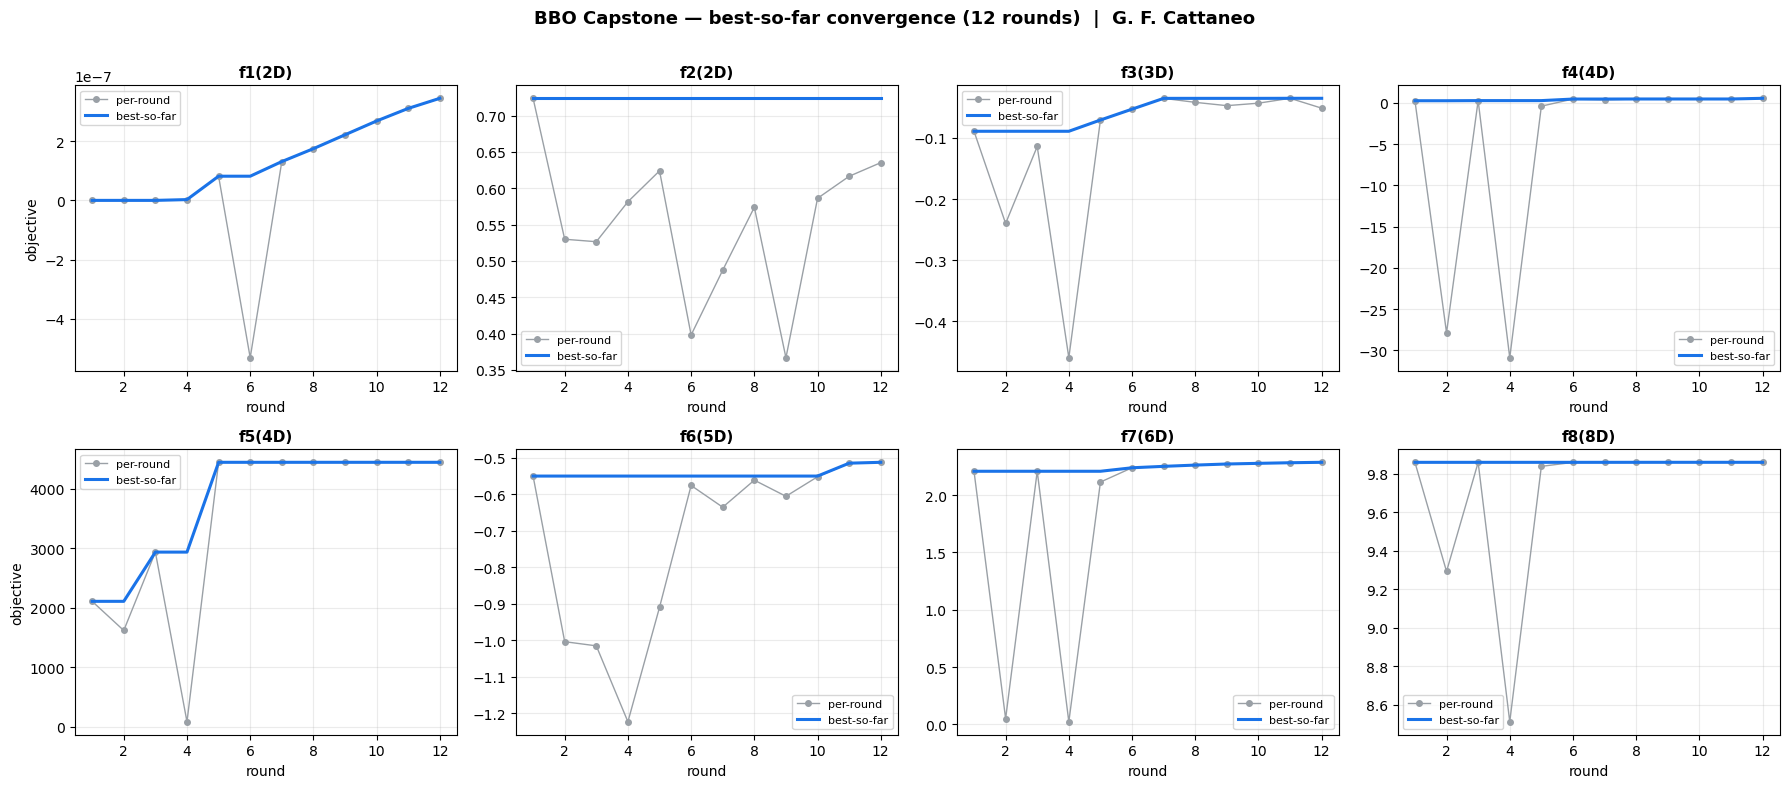

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for j, ax in enumerate(axes.ravel()):
    Yj = data[j][1]
    running = np.maximum.accumulate(Yj)
    rounds = np.arange(1, R + 1)
    ax.plot(rounds, Yj, "o-", color="#9aa0a6", lw=1, ms=4, label="per-round")
    ax.plot(rounds, running, "-", color="#1a73e8", lw=2.2, label="best-so-far")
    ax.set_title(NAMES[j], fontsize=11, weight="bold")
    ax.set_xlabel("round"); ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="best")
axes.ravel()[0].set_ylabel("objective"); axes.ravel()[4].set_ylabel("objective")
fig.suptitle("BBO Capstone — best-so-far convergence (12 rounds)  |  G. F. Cattaneo",
             fontsize=13, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("round13_convergence.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Closing note

The single irreducible case is **f2**: noise of sd ≈ 0.10 on a ≈ 0.72 signal means no
policy refinement converges cleanly, so the terminal-optimal action is to re-pull the
best-known arm rather than chase a phantom gradient — the project's clearest reminder
that in a stochastic-reward environment, exploitation means *re-sampling the incumbent*,
not extrapolating from it.

*End of Round 13 — final submission.*